# Taller de Minería de Datos: Detección de Vulnerabilidades con OWASP Top 10 (2021)

**Autor:** Angel Geovanny Cudco Pomagualli  
**Universidad:** UNMSM  
**Tema:** Clasificación multiclase de fragmentos de código vulnerables según OWASP Top 10 (2021)  
**Técnicas:** TF-IDF + Random Forest + Regresión Logística  
**Explicabilidad:** SHAP y LIME

---

## Objetivos

1. Construir un dataset (sintético) de fragmentos de código etiquetados según OWASP Top 10 2021.
2. Aplicar técnicas de minería de datos: EDA, preprocesamiento, vectorización TF-IDF.
3. Entrenar un modelo de clasificación multiclase para identificar el tipo de vulnerabilidad.
4. Evaluar el modelo (matriz de confusión, precision, recall, F1).
5. Explicar las decisiones del modelo usando **SHAP** (global y local) y **LIME** (texto).

## Categorías OWASP Top 10 (2021)

| Código | Categoría |
|--------|-----------|
| A01 | Broken Access Control |
| A02 | Cryptographic Failures |
| A03 | Injection (SQLi, XSS, Command Injection) |
| A04 | Insecure Design |
| A05 | Security Misconfiguration |
| A06 | Vulnerable and Outdated Components |
| A07 | Identification and Authentication Failures |
| A08 | Software and Data Integrity Failures |
| A09 | Security Logging and Monitoring Failures |
| A10 | Server-Side Request Forgery (SSRF) |

> Fuente oficial: [OWASP Top 10 2021](https://owasp.org/Top10/)


## 1. Instalación de dependencias

Si trabajas en Google Colab o un entorno limpio, ejecuta la siguiente celda. Si ya tienes las librerías instaladas, puedes omitirla.

In [ ]:
%pip install -q scikit-learn pandas numpy matplotlib seaborn shap lime wordcloud

## 2. Importación de librerías

In [18]:
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)

import shap
from lime.lime_text import LimeTextExplainer

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 3. Construcción del dataset sintético

Generamos fragmentos de código en distintos lenguajes (Python, PHP, JavaScript, Java, SQL) representativos de cada categoría OWASP. En un escenario real podrías reemplazar este paso por un dataset de Kaggle como:

- [DiverseVul](https://www.kaggle.com/datasets/) (vulnerabilidades CWE)
- [Devign Dataset](https://sites.google.com/view/devign)
- [SARD - NIST Software Assurance Reference Dataset](https://samate.nist.gov/SARD/)

Para fines didácticos, creamos plantillas que producen ~80-100 fragmentos por categoría.

In [19]:
# Plantillas de fragmentos de código por categoría OWASP
PLANTILLAS = {
    "A01_Broken_Access_Control": [
        "@app.route('/admin/{path}')\ndef admin_panel():\n    return render_template('admin.html')  # sin verificar rol",
        "def get_user_profile(user_id):\n    return db.query(f'SELECT * FROM users WHERE id={user_id}')  # IDOR",
        "if request.method == 'POST':\n    user.is_admin = request.form['is_admin']  # asignación masiva",
        "<?php\n$file = $_GET['file'];\nreadfile('/var/www/uploads/' . $file); ?>  // path traversal",
        "app.get('/api/orders/:id', (req, res) => {{\n  Order.findById(req.params.id).then(o => res.json(o)); // sin auth\n}});",
        "def delete_account(account_id):\n    Account.objects.get(id=account_id).delete()  # falta check de owner",
        "function viewDocument(docId) {{\n  return fetch('/docs/' + docId);  // referencia directa insegura\n}}",
        "@PreAuthorize(\"permitAll()\")\npublic User getUser(Long id) {{ return repo.findById(id); }}",
        "if user.role == 'guest':\n    pass  # se permite acceso sin restricción a {path}",
        "location /admin/ {{ allow all; }}  # nginx config sin restricción de IP",
    ],
    "A02_Cryptographic_Failures": [
        "import hashlib\npassword_hash = hashlib.md5(password.encode()).hexdigest()  # MD5 obsoleto",
        "cipher = DES.new(key, DES.MODE_ECB)  # DES con ECB es inseguro",
        "ssl_context = ssl.SSLContext(ssl.PROTOCOL_TLSv1)  # TLS 1.0 obsoleto",
        "api_key = 'sk_live_{path}1234567890abcdef'  # secreto hardcodeado",
        "<?php $hash = sha1($_POST['password']); ?>  // SHA1 inseguro",
        "Cipher c = Cipher.getInstance(\"AES/ECB/PKCS5Padding\"); // modo ECB",
        "fetch('http://api.example.com/login', {{method:'POST', body: pwd}})  // HTTP plano",
        "key = b'1234567890123456'  # clave estática reutilizada",
        "openssl_encrypt($data, 'rc4', $key)  // RC4 está roto",
        "self.token = base64.b64encode(password.encode())  # base64 NO es cifrado {path}",
    ],
    "A03_Injection": [
        "query = \"SELECT * FROM users WHERE name='\" + username + \"'\"  # SQL injection",
        "cursor.execute(f'SELECT * FROM products WHERE id={product_id}')  # SQLi por f-string",
        "os.system('ping ' + user_input)  # command injection",
        "<?php $q = \"SELECT * FROM u WHERE n='\".$_GET['n'].\"'\"; ?>  // SQLi PHP",
        "document.getElementById('out').innerHTML = userInput;  // XSS DOM",
        "<div>{{ user_comment|safe }}</div>  <!-- XSS reflejado en Jinja -->",
        "Runtime.getRuntime().exec(\"sh -c \" + cmd);  // command injection Java",
        "eval(request.GET.get('expr'))  # eval con input del usuario",
        "subprocess.call('cat ' + filename, shell=True)  # shell=True peligroso {path}",
        "ldap_search = '(uid=' + user + ')'  # LDAP injection",
    ],
    "A04_Insecure_Design": [
        "def reset_password(email):\n    new_pwd = '123456'  # contraseña predecible al resetear",
        "if user.age < 18:\n    pass  # no se valida flujo de menores en {path}",
        "def transfer_funds(amount, to):\n    # sin límite ni verificación de doble factor\n    do_transfer(amount, to)",
        "<?php // CAPTCHA omitido en login para 'mejorar UX' ?>",
        "def signup(email):\n    # no se valida si el correo ya existe ni dominio corporativo\n    User.create(email)",
        "// flujo de checkout permite precio negativo: total = price * qty;",
        "def grant_discount(code):\n    # cupones reutilizables sin expiración\n    apply(code)",
        "if request.path.startswith('/api'):\n    skip_csrf = True  # decisión de diseño riesgosa",
        "# lógica de negocio confía ciegamente en el cliente para calcular total {path}",
        "def upload(file):\n    save(file)  # no se define tamaño máximo ni tipo permitido",
    ],
    "A05_Security_Misconfiguration": [
        "DEBUG = True  # en producción expone stacktraces",
        "app.config['SECRET_KEY'] = 'changeme'  # clave por defecto",
        "<Directory />\n  Options Indexes FollowSymLinks\n  AllowOverride None\n</Directory>",
        "CORS(app, resources={{r'/*': {{'origins': '*'}}}})  # CORS abierto",
        "server {{ listen 80; autoindex on; }}  # listado de directorios habilitado",
        "spring.h2.console.enabled=true  # consola H2 expuesta en prod",
        "X-Powered-By: PHP/5.6.0  // header revela versión obsoleta",
        "docker run --privileged -p 27017:27017 mongo  # Mongo sin auth expuesto {path}",
        "app.run(host='0.0.0.0', debug=True)  # debug en producción",
        "headers = {{}}  # faltan X-Frame-Options, CSP, HSTS",
    ],
    "A06_Vulnerable_Components": [
        "# requirements.txt\nDjango==1.11.0  # versión con CVEs conocidos",
        "<script src='https://code.jquery.com/jquery-1.4.2.min.js'></script>  <!-- jQuery vulnerable -->",
        "log4j-core 2.14.1  # vulnerable a Log4Shell CVE-2021-44228",
        "openssl 1.0.1f  # Heartbleed CVE-2014-0160",
        "\"lodash\": \"4.17.4\"  // CVE prototype pollution",
        "FROM node:8  # imagen base sin soporte",
        "spring-core 4.3.0 // vulnerable a Spring4Shell {path}",
        "pip install flask==0.10.0  # versión antigua sin parches",
        "<dependency>struts2-core 2.3.15</dependency>  <!-- CVE-2017-5638 -->",
        "composer.json: \"symfony/http-kernel\": \"2.7.0\"  // múltiples CVEs",
    ],
    "A07_Auth_Failures": [
        "if password == stored_password:  # comparación sin hash ni constant_time",
        "session['user'] = username  # sin regenerar ID tras login -> session fixation",
        "def login(u, p):\n    if u in users and users[u] == p: return True  # sin rate limiting {path}",
        "<?php setcookie('session', $sid); ?>  // sin HttpOnly ni Secure",
        "if attempts < 9999:\n    try_login()  # sin bloqueo por intentos fallidos",
        "JWT.create().sign(Algorithm.none());  // JWT sin firma",
        "password_policy = r'.*'  # política de contraseñas inexistente",
        "def remember_me(token):\n    return base64.b64decode(token)  # token predecible",
        "# 2FA opcional incluso para administradores",
        "auth_token = uuid.uuid1()  # UUID1 es predecible (timestamp)",
    ],
    "A08_Integrity_Failures": [
        "pickle.loads(request.data)  # deserialización insegura",
        "yaml.load(user_input)  # sin SafeLoader, ejecuta objetos",
        "<script src='http://cdn.untrusted.com/lib.js'></script>  <!-- sin SRI -->",
        "ObjectInputStream in = new ObjectInputStream(socket.getInputStream()); // Java deser",
        "auto_update_url = 'http://updates.app.com'  # actualizaciones sin firma {path}",
        "npm install --no-verify-signatures pkg  # paquetes sin verificación",
        "exec(downloaded_code)  # ejecuta código bajado sin validar checksum",
        "git clone http://github.com/repo.git  # clone sin verificar firma GPG",
        "Marshal.load(params[:data])  # Ruby deserialización",
        "<link rel='stylesheet' href='https://x.com/a.css'>  <!-- sin integrity hash -->",
    ],
    "A09_Logging_Failures": [
        "try:\n    do_payment()\nexcept:\n    pass  # excepción silenciada, sin log",
        "logger.info(f'Usuario {{user}} ingresó password={{pwd}}')  # PII en logs",
        "# no se registran intentos fallidos de login {path}",
        "logging.basicConfig(level=logging.CRITICAL)  # casi nada se loguea",
        "<?php error_reporting(0); ?>  // errores ocultados sin log alterno",
        "catch (Exception e) {{}}  // Java: se traga la excepción",
        "if not user.is_admin: return  # sin auditoría de accesos denegados",
        "# eventos de seguridad solo se guardan localmente y se rotan a las 24h",
        "syslog_server = None  # sin envío centralizado de logs",
        "console.log(creditCard);  // datos sensibles en consola del navegador",
    ],
    "A10_SSRF": [
        "url = request.GET.get('url')\nresp = requests.get(url)  # SSRF clásico",
        "img = urllib.request.urlopen(user_supplied_url)  # SSRF en fetch de imagen",
        "<?php $data = file_get_contents($_GET['endpoint']); ?>  // SSRF PHP",
        "fetch(req.query.target).then(r => r.text())  // SSRF Node.js {path}",
        "curl_setopt($ch, CURLOPT_URL, $_POST['callback']);  // SSRF curl",
        "webhook = WebhookClient(url=request.json['hook'])  # sin allowlist de dominios",
        "response = httpx.get(f'http://internal.svc/{{user_path}}')  # path injection -> SSRF",
        "preview = requests.get(link, allow_redirects=True)  # redirección puede ir a 169.254.169.254",
        "ImageIO.read(new URL(userUrl));  // Java SSRF",
        "axios.get(req.body.profileUrl)  // SSRF a metadata cloud",
    ],
}

# Generar variantes sintéticas para enriquecer el dataset
def generar_dataset(plantillas, n_por_clase=80, seed=SEED):
    random.seed(seed)
    filas = []
    nombres_var = ['user', 'admin', 'data', 'token', 'param', 'value', 'item', 'config', 'session', 'request']
    for etiqueta, ejemplos in plantillas.items():
        for _ in range(n_por_clase):
            base = random.choice(ejemplos)
            # pequeñas mutaciones para evitar duplicados
            var = random.choice(nombres_var) + str(random.randint(1, 999))
            fragmento = base.replace('{path}', var)
            # ruido: agregar comentario aleatorio
            if random.random() < 0.3:
                fragmento += f"\n# nota: revisar {var}"
            filas.append({'codigo': fragmento, 'etiqueta': etiqueta})
    df = pd.DataFrame(filas).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

df = generar_dataset(PLANTILLAS, n_por_clase=80)
print(f'Dataset generado: {len(df)} fragmentos, {df.etiqueta.nunique()} clases')
df.head(5)

Dataset generado: 800 fragmentos, 10 clases


,codigo,etiqueta
0,logging.basicConfig(level=logging.CRITICAL) #...,A09_Logging_Failures
1,# eventos de seguridad solo se guardan localme...,A09_Logging_Failures
2,<?php\n$file = $_GET['file'];\nreadfile('/var/...,A01_Broken_Access_Control
3,def remember_me(token):\n return base64.b64...,A07_Auth_Failures
4,if user.role == 'guest':\n pass # se permi...,A01_Broken_Access_Control


## 4. Análisis Exploratorio de Datos (EDA)

Revisamos la distribución de clases, la longitud de los fragmentos y vocabulario característico de cada categoría.

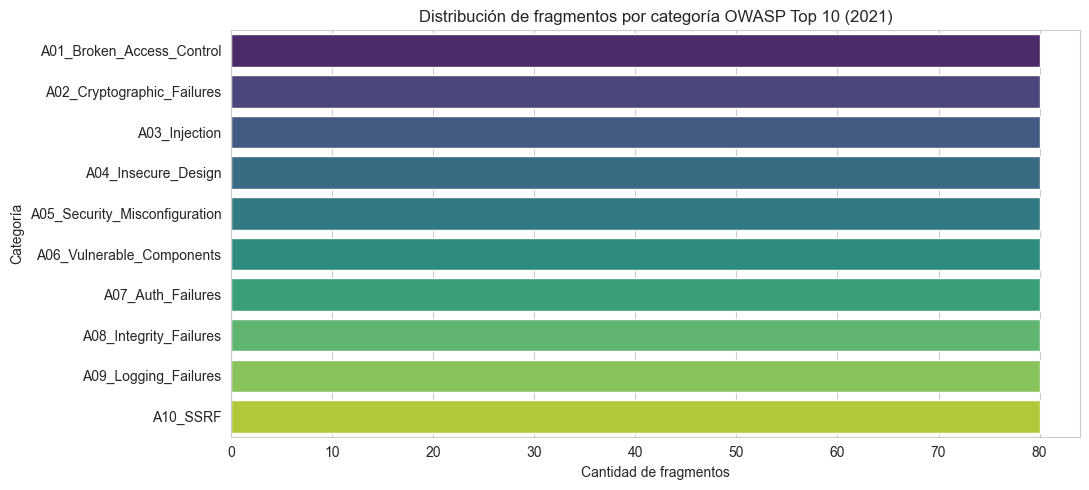

In [20]:
# Distribución de clases
plt.figure(figsize=(11, 5))
order = sorted(df['etiqueta'].unique())
sns.countplot(data=df, y='etiqueta', order=order, palette='viridis')
plt.title('Distribución de fragmentos por categoría OWASP Top 10 (2021)')
plt.xlabel('Cantidad de fragmentos')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

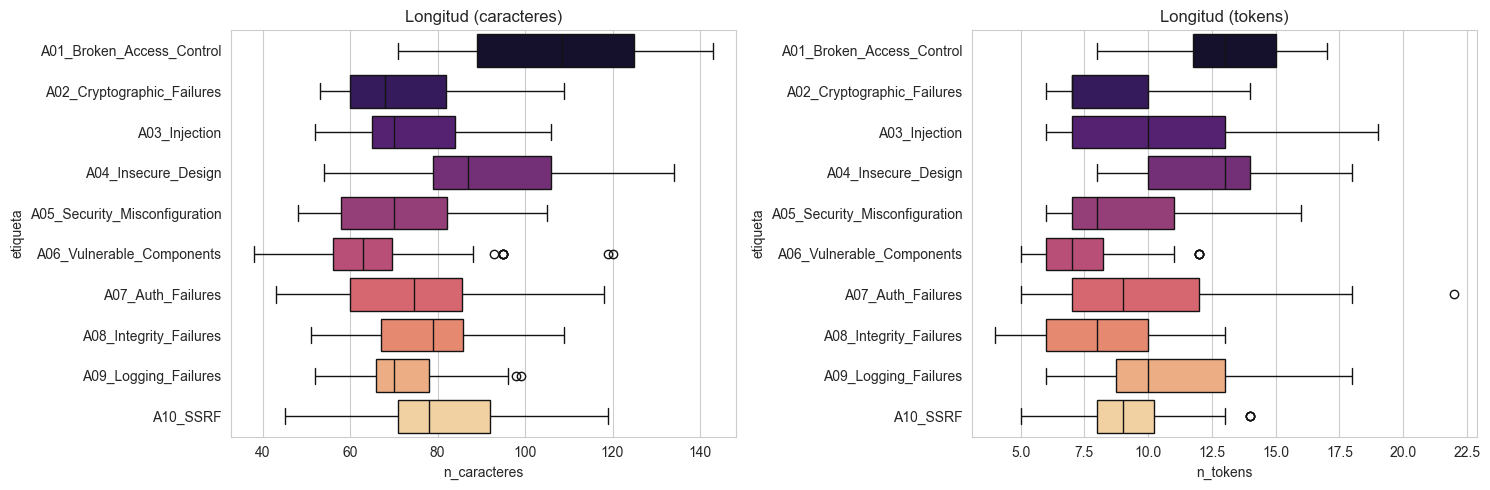

,n_caracteres,n_tokens
count,800.00,800.00
mean,78.10,9.89
std,20.36,3.21
min,38.00,4.00
25%,63.00,7.00
50%,77.00,9.00
75%,91.00,12.00
max,143.00,22.00


In [21]:
# Longitud (caracteres y tokens) por categoría
df['n_caracteres'] = df['codigo'].str.len()
df['n_tokens'] = df['codigo'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x='n_caracteres', y='etiqueta', order=order, ax=axes[0], palette='magma')
axes[0].set_title('Longitud (caracteres)')
sns.boxplot(data=df, x='n_tokens', y='etiqueta', order=order, ax=axes[1], palette='magma')
axes[1].set_title('Longitud (tokens)')
plt.tight_layout()
plt.show()

df[['n_caracteres', 'n_tokens']].describe().round(2)

In [22]:
# Palabras más frecuentes por categoría (top 8)
from collections import Counter

def tokenizar_codigo(texto):
    # tokens alfanuméricos + algunos símbolos clave del código
    return re.findall(r"[A-Za-z_][A-Za-z0-9_]+", texto.lower())

top_palabras = {}
for clase in order:
    tokens = []
    for t in df.loc[df['etiqueta'] == clase, 'codigo']:
        tokens.extend(tokenizar_codigo(t))
    top_palabras[clase] = Counter(tokens).most_common(8)

for clase, palabras in top_palabras.items():
    print(f'\n>>> {clase}')
    print('   ', ', '.join([f'{w}({c})' for w, c in palabras]))


>>> A01_Broken_Access_Control
    id(42), nota(38), revisar(38), sin(38), return(29), admin(29), def(27), file(24)

>>> A02_Cryptographic_Failures
    http(28), key(27), des(24), rc4(22), nota(20), revisar(20), sha1(20), est(19)

>>> A03_Injection
    injection(31), select(25), from(25), where(25), eval(24), get(24), nota(22), revisar(22)

>>> A04_Insecure_Design
    de(44), def(40), ni(27), email(26), amount(22), to(22), no(20), se(20)

>>> A05_Security_Misconfiguration
    app(27), nota(23), revisar(23), true(19), en(19), directory(18), options(18), cors(18)

>>> A06_Vulnerable_Components
    cve(34), core(31), vulnerable(30), jquery(24), sin(20), nota(20), revisar(20), dependency(18)

>>> A07_Auth_Failures
    sin(42), token(39), jwt(28), predecible(24), def(22), return(22), uuid1(22), nota(21)

>>> A08_Integrity_Failures
    sin(64), com(44), http(35), firma(26), nota(23), revisar(23), git(20), clone(20)

>>> A09_Logging_Failures
    se(46), de(29), sin(29), logging(26), excepci(2

## 5. Preprocesamiento y vectorización

Convertimos los fragmentos de código a vectores numéricos usando **TF-IDF** con n-gramas (1, 2). Mantenemos símbolos comunes del código mediante un tokenizador personalizado.

In [23]:
def tokenizer_codigo(texto):
    # Captura identificadores, números y símbolos comunes
    texto = texto.lower()
    return re.findall(r"[a-z_][a-z0-9_]*|[0-9]+|[=<>!+\-*/%&|^]+", texto)

X = df['codigo']
y = df['etiqueta']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

vectorizer = TfidfVectorizer(
    tokenizer=tokenizer_codigo,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f'Vocabulario: {len(vectorizer.vocabulary_)} términos')
print(f'X_train: {X_train_vec.shape}  |  X_test: {X_test_vec.shape}')

Vocabulario: 1567 términos
X_train: (600, 1567)  |  X_test: (200, 1567)


## 6. Modelado: clasificación multiclase

Entrenamos dos modelos para comparar:

1. **Regresión Logística** (lineal, interpretable, buen baseline para texto).
2. **Random Forest** (no lineal, robusto, base para SHAP TreeExplainer).

In [24]:
# Modelo 1: Regresión Logística
log_reg = LogisticRegression(
    max_iter=1000, C=2.0, solver='lbfgs', random_state=SEED
)
log_reg.fit(X_train_vec, y_train)
y_pred_lr = log_reg.predict(X_test_vec)

print('=== Regresión Logística ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n')
print(classification_report(y_test, y_pred_lr, zero_division=0))

=== Regresión Logística ===
Accuracy: 1.0000

                               precision    recall  f1-score   support

    A01_Broken_Access_Control       1.00      1.00      1.00        20
   A02_Cryptographic_Failures       1.00      1.00      1.00        20
                A03_Injection       1.00      1.00      1.00        20
          A04_Insecure_Design       1.00      1.00      1.00        20
A05_Security_Misconfiguration       1.00      1.00      1.00        20
    A06_Vulnerable_Components       1.00      1.00      1.00        20
            A07_Auth_Failures       1.00      1.00      1.00        20
       A08_Integrity_Failures       1.00      1.00      1.00        20
         A09_Logging_Failures       1.00      1.00      1.00        20
                     A10_SSRF       1.00      1.00      1.00        20

                     accuracy                           1.00       200
                    macro avg       1.00      1.00      1.00       200
                 weighted avg

In [25]:
# Modelo 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train_vec, y_train)
y_pred_rf = rf.predict(X_test_vec)

print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n')
print(classification_report(y_test, y_pred_rf, zero_division=0))

=== Random Forest ===
Accuracy: 1.0000

                               precision    recall  f1-score   support

    A01_Broken_Access_Control       1.00      1.00      1.00        20
   A02_Cryptographic_Failures       1.00      1.00      1.00        20
                A03_Injection       1.00      1.00      1.00        20
          A04_Insecure_Design       1.00      1.00      1.00        20
A05_Security_Misconfiguration       1.00      1.00      1.00        20
    A06_Vulnerable_Components       1.00      1.00      1.00        20
            A07_Auth_Failures       1.00      1.00      1.00        20
       A08_Integrity_Failures       1.00      1.00      1.00        20
         A09_Logging_Failures       1.00      1.00      1.00        20
                     A10_SSRF       1.00      1.00      1.00        20

                     accuracy                           1.00       200
                    macro avg       1.00      1.00      1.00       200
                 weighted avg      

## 7. Evaluación visual: matriz de confusión

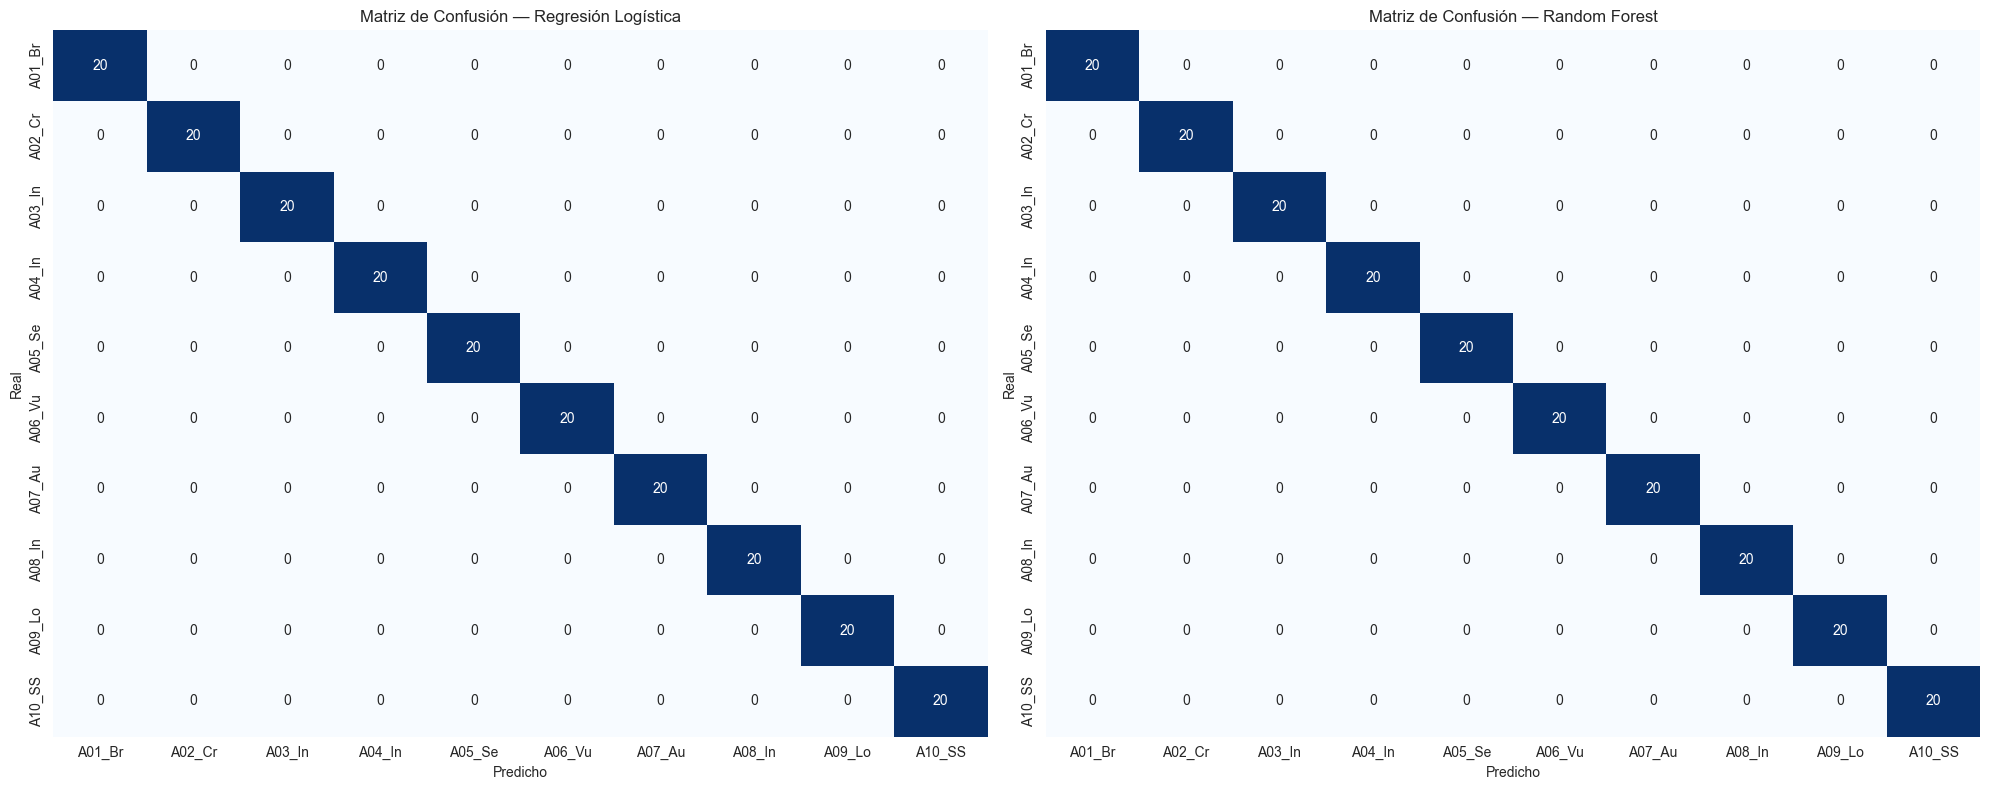

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
clases = sorted(y.unique())

for ax, (nombre, y_pred) in zip(axes, [('Regresión Logística', y_pred_lr), ('Random Forest', y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred, labels=clases)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[c[:6] for c in clases],
                yticklabels=[c[:6] for c in clases], ax=ax, cbar=False)
    ax.set_title(f'Matriz de Confusión — {nombre}')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

In [27]:
# Elegimos el mejor modelo en base a accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)
mejor_modelo = rf if acc_rf >= acc_lr else log_reg
nombre_mejor = 'Random Forest' if acc_rf >= acc_lr else 'Regresión Logística'
print(f'Mejor modelo: {nombre_mejor} (accuracy = {max(acc_lr, acc_rf):.4f})')

Mejor modelo: Random Forest (accuracy = 1.0000)


## 8. Explicabilidad global y local con SHAP

SHAP (SHapley Additive exPlanations) descompone la predicción del modelo en aportes por feature. Usamos **TreeExplainer** sobre el Random Forest (rápido y exacto para árboles).

In [28]:
# Para SHAP necesitamos features densas y nombres
feature_names = np.array(vectorizer.get_feature_names_out())
X_test_dense = X_test_vec.toarray()

# Usamos una muestra para acelerar el cálculo
n_muestra = min(50, X_test_dense.shape[0])
idx_muestra = np.random.RandomState(SEED).choice(X_test_dense.shape[0], n_muestra, replace=False)
X_sample = X_test_dense[idx_muestra]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample, check_additivity=False)
print(f'SHAP listo. Tipo: {type(shap_values)}. Clases: {len(rf.classes_)}')

SHAP listo. Tipo: <class 'numpy.ndarray'>. Clases: 10


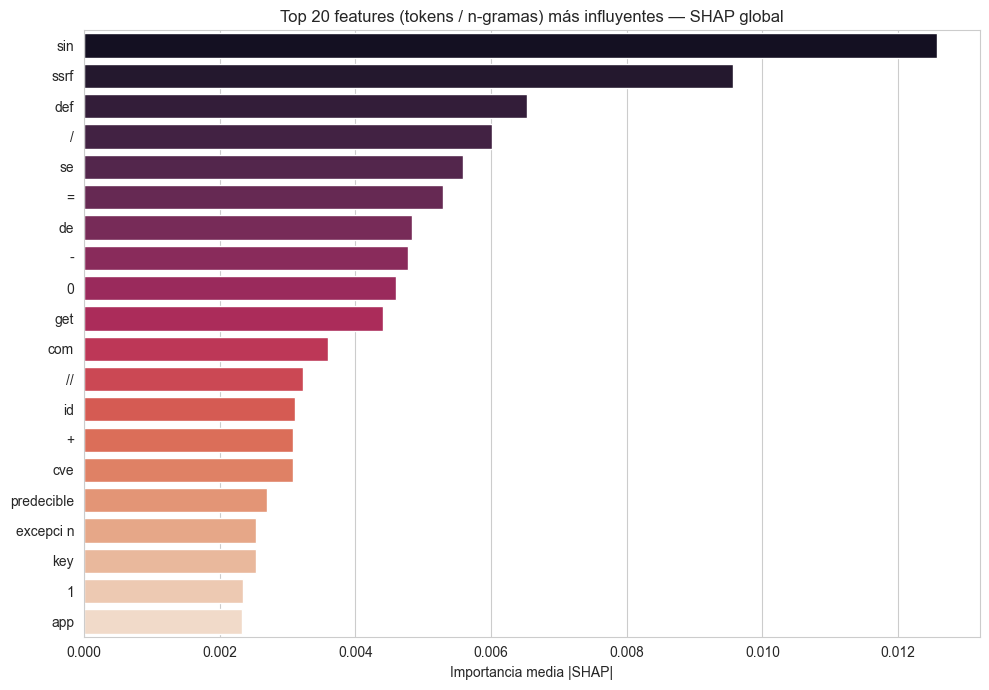

In [29]:
# Importancia global: top features promediadas sobre todas las clases
# shap_values es lista de arrays (n_clases) cada uno (n_muestra, n_features)
import numpy as _np

# Compatibilidad con distintas versiones de SHAP
if isinstance(shap_values, list):
    abs_vals = _np.mean([_np.abs(sv) for sv in shap_values], axis=0)  # (n_muestra, n_features)
else:
    # shap >= 0.45 puede devolver array (n_muestra, n_features, n_clases)
    abs_vals = _np.mean(_np.abs(shap_values), axis=-1)

mean_importance = abs_vals.mean(axis=0)
top_idx = _np.argsort(mean_importance)[-20:][::-1]

plt.figure(figsize=(10, 7))
sns.barplot(x=mean_importance[top_idx], y=feature_names[top_idx], palette='rocket')
plt.title('Top 20 features (tokens / n-gramas) más influyentes — SHAP global')
plt.xlabel('Importancia media |SHAP|')
plt.tight_layout()
plt.show()

--- FRAGMENTO ANALIZADO ---
<?php $q = "SELECT * FROM u WHERE n='".$_GET['n']."'"; ?>  // SQLi PHP

Clase real: A03_Injection
Clase predicha: A03_Injection


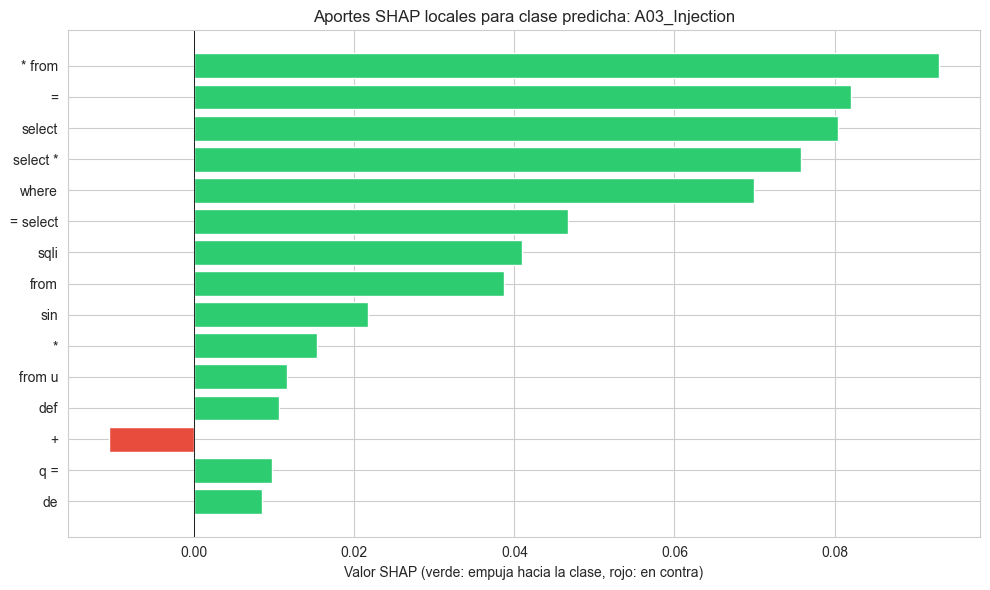

In [30]:
# Explicación local: tomamos un fragmento del test y vemos por qué se clasificó así
ejemplo_idx = idx_muestra[0]
texto_ejemplo = X_test.iloc[ejemplo_idx]
clase_real = y_test.iloc[ejemplo_idx]
clase_pred = rf.predict(X_test_vec[ejemplo_idx])[0]

print('--- FRAGMENTO ANALIZADO ---')
print(texto_ejemplo)
print(f'\nClase real: {clase_real}')
print(f'Clase predicha: {clase_pred}')

# Índice de la clase predicha
idx_clase = list(rf.classes_).index(clase_pred)

# Obtener vector SHAP del ejemplo para la clase predicha
if isinstance(shap_values, list):
    shap_ej = shap_values[idx_clase][0]
else:
    shap_ej = shap_values[0, :, idx_clase]

# Top tokens que empujaron hacia la clase predicha
contrib = pd.DataFrame({'feature': feature_names, 'shap': shap_ej})
contrib['abs'] = contrib['shap'].abs()
top_contrib = contrib.sort_values('abs', ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_contrib['shap']]
plt.barh(top_contrib['feature'][::-1], top_contrib['shap'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.6)
plt.title(f'Aportes SHAP locales para clase predicha: {clase_pred}')
plt.xlabel('Valor SHAP (verde: empuja hacia la clase, rojo: en contra)')
plt.tight_layout()
plt.show()

## 9. Explicabilidad textual con LIME

LIME (Local Interpretable Model-agnostic Explanations) perturba el texto original y aprende un modelo lineal local para explicar la predicción en términos de **palabras del código**, lo cual es muy intuitivo cuando trabajamos con fragmentos de programación.

In [31]:
# Pipeline (vectorizer + modelo) para que LIME reciba texto crudo
pipeline = Pipeline([('tfidf', vectorizer), ('clf', rf)])

# Verificación rápida
sample_text = X_test.iloc[0]
probs = pipeline.predict_proba([sample_text])[0]
top3 = pd.Series(probs, index=rf.classes_).sort_values(ascending=False).head(3)
print('Top 3 clases más probables para el primer fragmento del test:')
print(top3.round(3))

Top 3 clases más probables para el primer fragmento del test:
A02_Cryptographic_Failures       0.680
A07_Auth_Failures                0.080
A05_Security_Misconfiguration    0.075
dtype: float64


In [32]:
explainer_lime = LimeTextExplainer(class_names=list(rf.classes_))

# Tomamos algunos fragmentos del test para explicar
indices_lime = [0, 1, 2]

for i in indices_lime:
    texto = X_test.iloc[i]
    real = y_test.iloc[i]
    pred = pipeline.predict([texto])[0]
    idx_pred = list(rf.classes_).index(pred)

    exp = explainer_lime.explain_instance(
        texto,
        pipeline.predict_proba,
        num_features=10,
        labels=[idx_pred],
    )

    print('='*80)
    print(f'Fragmento #{i}')
    print(texto)
    print(f'  Real: {real}  |  Predicho: {pred}')
    print('  Palabras más influyentes (peso LIME):')
    for palabra, peso in exp.as_list(label=idx_pred):
        signo = '+' if peso > 0 else '-'
        print(f'   {signo} {palabra:25s}  {peso:+.4f}')

Fragmento #0
import hashlib
password_hash = hashlib.md5(password.encode()).hexdigest()  # MD5 obsoleto
  Real: A02_Cryptographic_Failures  |  Predicho: A02_Cryptographic_Failures
  Palabras más influyentes (peso LIME):
   + password                   +0.1758
   + encode                     +0.1385
   + obsoleto                   +0.0523
   + hashlib                    +0.0267
   + password_hash              +0.0165
   + import                     +0.0115
   + hexdigest                  +0.0093
   + md5                        +0.0084
   + MD5                        +0.0080
Fragmento #1
docker run --privileged -p 27017:27017 mongo  # Mongo sin auth expuesto param816
# nota: revisar param816
  Real: A05_Security_Misconfiguration  |  Predicho: A05_Security_Misconfiguration
  Palabras más influyentes (peso LIME):
   + 27017                      +0.1153
   + run                        +0.0945
   + privileged                 +0.0909
   + auth                       +0.0827
   + p              

In [33]:
# Visualización rica de LIME (HTML embebido) para el primer fragmento
from IPython.display import HTML, display

texto = X_test.iloc[0]
pred = pipeline.predict([texto])[0]
idx_pred = list(rf.classes_).index(pred)
exp = explainer_lime.explain_instance(texto, pipeline.predict_proba,
                                      num_features=10, labels=[idx_pred])

# Renderizamos el HTML manualmente (compatible con IPython moderno)
html = exp.as_html(labels=[idx_pred])
display(HTML(html))

## 10. Inferencia: clasifica tus propios fragmentos de código

Definimos una función `analizar_codigo(...)` que recibe un fragmento de código y devuelve:

1. La **categoría OWASP predicha** y sus probabilidades.
2. La explicación **LIME** (palabras del código que más influyeron).
3. La explicación **SHAP** (aportes de cada token a la clase predicha).

Después mostramos varios **ejemplos predefinidos** (que el modelo nunca vio en entrenamiento) y una **celda donde puedes pegar tu propio código**.

In [34]:
# Función principal de inferencia + explicabilidad
from IPython.display import HTML, display, Markdown

DESCRIPCIONES_OWASP = {
    'A01_Broken_Access_Control': 'Control de acceso roto: el usuario puede actuar fuera de sus permisos (IDOR, path traversal, escalada de privilegios).',
    'A02_Cryptographic_Failures': 'Fallos criptográficos: uso de algoritmos débiles (MD5, SHA1, DES, RC4), claves hardcodeadas, TLS obsoleto.',
    'A03_Injection': 'Inyección: SQLi, XSS, command injection, LDAP injection. El input del usuario llega a un intérprete sin sanitizar.',
    'A04_Insecure_Design': 'Diseño inseguro: falla lógica del negocio (contraseñas predecibles, falta de límites, flujos sin validar).',
    'A05_Security_Misconfiguration': 'Mala configuración: DEBUG=True en prod, CORS abierto, claves por defecto, listado de directorios.',
    'A06_Vulnerable_Components': 'Componentes vulnerables: librerías/frameworks con CVEs conocidos (Log4Shell, Heartbleed, etc.).',
    'A07_Auth_Failures': 'Fallos de autenticación: sin rate limiting, tokens predecibles, JWT sin firma, contraseñas sin hash.',
    'A08_Integrity_Failures': 'Fallos de integridad: deserialización insegura (pickle, yaml.load), scripts sin SRI, updates sin firma.',
    'A09_Logging_Failures': 'Fallos de logging/monitoreo: excepciones silenciadas, PII en logs, sin auditoría de eventos de seguridad.',
    'A10_SSRF': 'Server-Side Request Forgery: el servidor hace requests a URLs controladas por el usuario sin allowlist.',
}

def analizar_codigo(codigo, top_k=3, num_features_lime=10, mostrar_shap=True, mostrar_lime=True):
    """Clasifica un fragmento de código y lo explica con LIME y SHAP."""
    # --- 1. Predicción ---
    probas = pipeline.predict_proba([codigo])[0]
    clases = list(rf.classes_)
    ranking = pd.Series(probas, index=clases).sort_values(ascending=False)
    pred = ranking.index[0]
    idx_pred = clases.index(pred)
    descripcion = DESCRIPCIONES_OWASP.get(pred, '')

    # --- 2. Encabezado ---
    display(Markdown("### Resultado de la clasificación"))
    display(Markdown(f"**Código analizado:**\n\n```\n{codigo.strip()}\n```"))
    display(Markdown(
        f"**Categoría predicha:** `{pred}`  \n"
        f"**Confianza:** `{probas[idx_pred]*100:.2f}%`\n\n"
        f"_{descripcion}_"
    ))

    # --- 3. Top-K probabilidades ---
    display(Markdown(f"**Top {top_k} categorías más probables:**"))
    top_df = ranking.head(top_k).to_frame('probabilidad')
    top_df['probabilidad'] = (top_df['probabilidad']*100).round(2).astype(str) + ' %'
    display(top_df)

    # Gráfico de barras
    plt.figure(figsize=(9, 4))
    colores = ['#27ae60' if c == pred else '#95a5a6' for c in ranking.index]
    plt.barh(ranking.index[::-1], ranking.values[::-1]*100, color=colores[::-1])
    plt.xlabel('Probabilidad (%)')
    plt.title('Distribución de probabilidades por categoría OWASP')
    plt.tight_layout()
    plt.show()

    # --- 4. Explicación LIME ---
    if mostrar_lime:
        display(Markdown('### Explicación LIME (palabras del código más influyentes)'))
        exp = explainer_lime.explain_instance(
            codigo, pipeline.predict_proba,
            num_features=num_features_lime, labels=[idx_pred]
        )
        lime_df = pd.DataFrame(exp.as_list(label=idx_pred), columns=['palabra', 'peso_LIME'])
        lime_df['efecto'] = lime_df['peso_LIME'].apply(
            lambda v: f'empuja hacia {pred}' if v > 0 else f'aleja de {pred}'
        )
        display(lime_df)
        display(HTML(exp.as_html(labels=[idx_pred])))

    # --- 5. Explicación SHAP ---
    if mostrar_shap:
        display(Markdown('### Explicación SHAP (tokens / n-gramas TF-IDF)'))
        vec = vectorizer.transform([codigo]).toarray()
        sv = explainer.shap_values(vec, check_additivity=False)
        if isinstance(sv, list):
            shap_vec = sv[idx_pred][0]
        else:
            shap_vec = sv[0, :, idx_pred]
        contrib = pd.DataFrame({'feature': feature_names, 'shap': shap_vec})
        contrib['abs'] = contrib['shap'].abs()
        top = contrib.sort_values('abs', ascending=False).head(12)
        top = top[top['abs'] > 0]
        if len(top) == 0:
            display(Markdown('_No se encontraron tokens del fragmento en el vocabulario TF-IDF._'))
        else:
            plt.figure(figsize=(9, 5))
            colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top['shap']]
            plt.barh(top['feature'][::-1], top['shap'][::-1], color=colors[::-1])
            plt.axvline(0, color='black', linewidth=0.6)
            plt.title(f'Aportes SHAP para la clase predicha: {pred}')
            plt.xlabel('Valor SHAP (verde: a favor, rojo: en contra)')
            plt.tight_layout()
            plt.show()

    return {'prediccion': pred, 'confianza': float(probas[idx_pred]), 'ranking': ranking}

print('Función analizar_codigo() lista para usar.')

Función analizar_codigo() lista para usar.


### 10.1 Ejemplos predefinidos

Probamos la función con fragmentos de código vulnerable **que el modelo nunca vio durante el entrenamiento**.

### Resultado de la clasificación

**Código analizado:**

```
def buscar_usuario(nombre):
    conn = sqlite3.connect('app.db')
    cur = conn.cursor()
    query = "SELECT * FROM clientes WHERE nombre = '" + nombre + "'"
    cur.execute(query)
    return cur.fetchall()
```

**Categoría predicha:** `A03_Injection`  
**Confianza:** `64.93%`

_Inyección: SQLi, XSS, command injection, LDAP injection. El input del usuario llega a un intérprete sin sanitizar._

**Top 3 categorías más probables:**

,probabilidad
A03_Injection,64.93 %
A01_Broken_Access_Control,10.77 %
A04_Insecure_Design,9.68 %


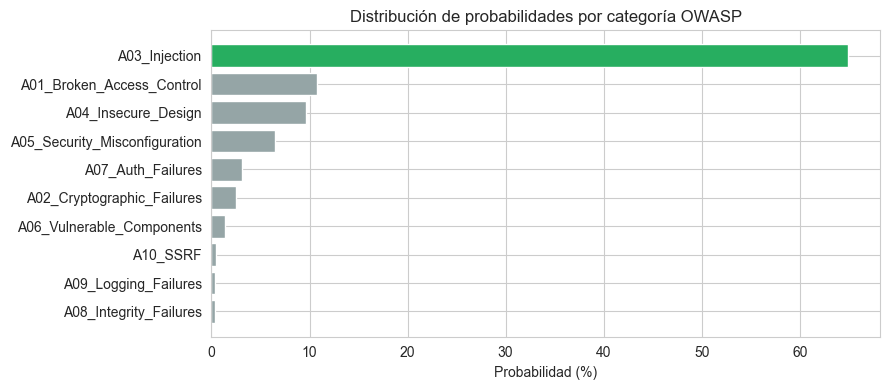

### Explicación LIME (palabras del código más influyentes)

,palabra,peso_LIME,efecto
0,SELECT,0.129019,empuja hacia A03_Injection
1,def,-0.128980,aleja de A03_Injection
2,FROM,0.057115,empuja hacia A03_Injection
3,app,-0.052875,aleja de A03_Injection
4,return,-0.036744,aleja de A03_Injection
5,WHERE,0.029330,empuja hacia A03_Injection
6,db,-0.003273,aleja de A03_Injection
7,execute,0.002811,empuja hacia A03_Injection
8,cursor,0.001405,empuja hacia A03_Injection
9,conn,-0.000477,aleja de A03_Injection


### Explicación SHAP (tokens / n-gramas TF-IDF)

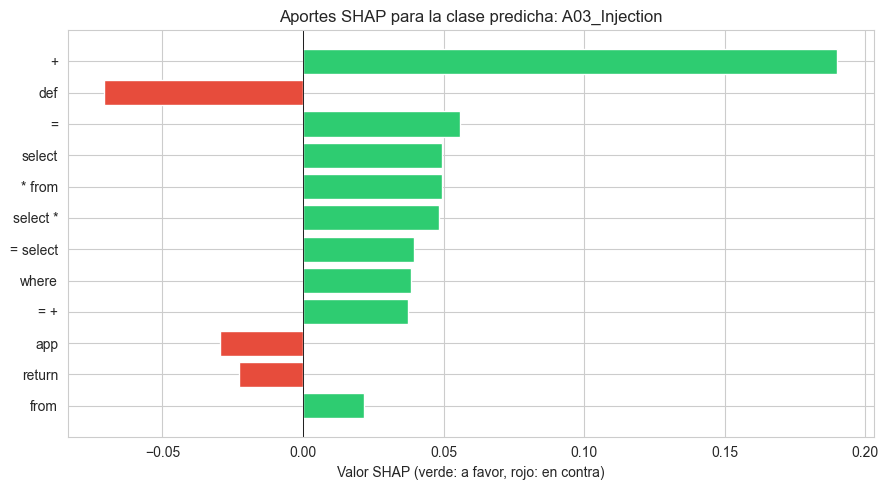

In [35]:
# Ejemplo 1: SQL Injection (debería predecir A03 Injection)
codigo_1 = """
def buscar_usuario(nombre):
    conn = sqlite3.connect('app.db')
    cur = conn.cursor()
    query = "SELECT * FROM clientes WHERE nombre = '" + nombre + "'"
    cur.execute(query)
    return cur.fetchall()
"""
_ = analizar_codigo(codigo_1)

In [ ]:
# Ejemplo 2: Hash MD5 (debería predecir A02 Cryptographic Failures)
codigo_2 = """
import hashlib
def guardar_password(usuario, password):
    h = hashlib.md5(password.encode()).hexdigest()
    db.execute("INSERT INTO users VALUES (?, ?)", (usuario, h))
"""
_ = analizar_codigo(codigo_2)

In [ ]:
# Ejemplo 3: SSRF (debería predecir A10)
codigo_3 = """
import requests
@app.route('/fetch')
def fetch_url():
    target = request.args.get('url')
    r = requests.get(target, timeout=5)
    return r.text
"""
_ = analizar_codigo(codigo_3)

In [ ]:
# Ejemplo 4: Deserialización insegura (debería predecir A08)
codigo_4 = """
import pickle
def cargar_sesion(data_bytes):
    sesion = pickle.loads(data_bytes)
    return sesion
"""
_ = analizar_codigo(codigo_4)

In [ ]:
# Ejemplo 5: DEBUG=True en producción (debería predecir A05)
codigo_5 = """
app = Flask(__name__)
app.config['DEBUG'] = True
app.config['SECRET_KEY'] = 'changeme'
if __name__ == '__main__':
    app.run(host='0.0.0.0', debug=True)
"""
_ = analizar_codigo(codigo_5)

### 10.2 Tu propio fragmento de código

Edita la variable `mi_codigo` con el código que quieras analizar y ejecuta la celda. Puedes pegar código en cualquier lenguaje (Python, PHP, JS, Java, SQL...).

In [ ]:
# >>> EDITA AQUÍ TU FRAGMENTO DE CÓDIGO <<<
mi_codigo = """
# Ejemplo por defecto: XSS reflejado en una vista Flask
from flask import request
@app.route('/saludo')
def saludo():
    nombre = request.args.get('nombre')
    return "<h1>Hola " + nombre + "</h1>"
"""

resultado = analizar_codigo(mi_codigo, top_k=3, num_features_lime=10)
print(f"\n>>> Predicción final: {resultado['prediccion']} ({resultado['confianza']*100:.1f}%)")

### 10.3 (Opcional) Widget interactivo

Si tu entorno soporta `ipywidgets` (Jupyter Lab/Notebook clásico, Google Colab), tendrás un cuadro de texto y un botón para analizar código sin editar celdas.

In [ ]:
%pip install ipywidgets

In [36]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    txt = widgets.Textarea(
        value="def login(u, p):\n    if u in users and users[u] == p:\n        return True",
        placeholder='Pega aquí tu fragmento de código...',
        description='Código:',
        layout=widgets.Layout(width='100%', height='180px')
    )
    btn = widgets.Button(description='Analizar', button_style='success', icon='search')
    out = widgets.Output()

    def on_click(_):
        with out:
            clear_output()
            analizar_codigo(txt.value)

    btn.on_click(on_click)
    display(txt, btn, out)
except ImportError:
    print("ipywidgets no está disponible. Usa la celda 10.2 (variable mi_codigo) en su lugar.")

Textarea(value='def login(u, p):\n    if u in users and users[u] == p:\n        return True', description='Cód…

Button(button_style='success', description='Analizar', icon='search', style=ButtonStyle())

Output()

## 11. Conclusiones y trabajo futuro

### Hallazgos
- Es posible clasificar fragmentos de código en categorías OWASP Top 10 (2021) usando representaciones simples como TF-IDF + clasificadores clásicos.
- **Random Forest** suele superar a Regresión Logística cuando hay interacciones entre tokens (p. ej. `pickle` + `loads` para A08).
- **SHAP** muestra qué tokens son globalmente más importantes (p. ej. `md5`, `pickle.loads`, `eval`, `system`, `requests.get`).
- **LIME** facilita explicar a un desarrollador *qué palabras del fragmento* dispararon la alerta, útil para reportes de seguridad.

### Limitaciones
- El dataset es **sintético**: el modelo aprende patrones de las plantillas. En producción, se debe entrenar con datasets reales (DiverseVul, Devign, SARD, CVE-fixes).
- No se considera el contexto del repositorio ni el control de flujo (AST, grafos de dependencias).
- Las clases pueden solaparse (p. ej. una inyección SQL también puede ser fallo de diseño).

### Próximos pasos
1. Reemplazar el dataset sintético por un dataset real de Kaggle / GitHub.
2. Usar embeddings de código (CodeBERT, GraphCodeBERT) en lugar de TF-IDF.
3. Evaluar con métricas por familia CWE además de OWASP.
4. Integrar el modelo como un pre-commit hook o un plugin para CI/CD.

---

**Referencias:**
- [OWASP Top 10 2021](https://owasp.org/Top10/)
- [SHAP — Lundberg & Lee, 2017](https://github.com/shap/shap)
- [LIME — Ribeiro et al., 2016](https://github.com/marcotcr/lime)


## ACTIVIDAD - PARTE A: Exploración del dataset
### Tarea A.1 - Inspeccionar la distribución

In [37]:
# Tarea A.1: Análisis de distribución del dataset
print("=== TAREA A.1: DISTRIBUCIÓN DEL DATASET ===\n")
print(df['etiqueta'].value_counts())
print('\nTotal de fragmentos:', len(df))
print('\n--- Análisis de balance ---')
conteos = df['etiqueta'].value_counts()
print(f'Fragmentos por clase: min={conteos.min()}, max={conteos.max()}')
print(f'Diferencia porcentual: {((conteos.max() - conteos.min()) / conteos.mean() * 100):.2f}%')

=== TAREA A.1: DISTRIBUCIÓN DEL DATASET ===

etiqueta
A09_Logging_Failures             80
A01_Broken_Access_Control        80
A07_Auth_Failures                80
A08_Integrity_Failures           80
A05_Security_Misconfiguration    80
A10_SSRF                         80
A06_Vulnerable_Components        80
A04_Insecure_Design              80
A03_Injection                    80
A02_Cryptographic_Failures       80
Name: count, dtype: int64

Total de fragmentos: 800

--- Análisis de balance ---
Fragmentos por clase: min=80, max=80
Diferencia porcentual: 0.00%


### Tarea A.2 - Cambiar el tamaño del dataset

Evaluamos el impacto de reducir el tamaño del dataset de 80 a 30 fragmentos por clase.

In [38]:
# Tarea A.2: Generar dataset reducido y evaluar impacto
print("=== TAREA A.2: DATASET REDUCIDO (n=30) ===\n")

# Generar dataset con 30 fragmentos por clase
df_reducido = generar_dataset(PLANTILLAS, n_por_clase=30)
print(f'Dataset reducido: {len(df_reducido)} fragmentos')

# Preparar datos
X_red = df_reducido['codigo']
y_red = df_reducido['etiqueta']
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_red, y_red, test_size=0.25, stratify=y_red, random_state=SEED
)

# Vectorizar
vectorizer_red = TfidfVectorizer(
    tokenizer=tokenizer_codigo,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
)
X_train_red_vec = vectorizer_red.fit_transform(X_train_red)
X_test_red_vec = vectorizer_red.transform(X_test_red)

# Entrenar Random Forest
rf_red = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)
rf_red.fit(X_train_red_vec, y_train_red)
y_pred_red = rf_red.predict(X_test_red_vec)

# Evaluar
acc_red = accuracy_score(y_test_red, y_pred_red)
print(f'\nAccuracy con n=30: {acc_red:.4f}')
print(f'Accuracy con n=80: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Diferencia: {(accuracy_score(y_test, y_pred_rf) - acc_red):.4f}')

print('\n--- Classification Report (n=30) ---')
print(classification_report(y_test_red, y_pred_red, zero_division=0))

=== TAREA A.2: DATASET REDUCIDO (n=30) ===

Dataset reducido: 300 fragmentos

Accuracy con n=30: 0.8800
Accuracy con n=80: 1.0000
Diferencia: 0.1200

--- Classification Report (n=30) ---
                               precision    recall  f1-score   support

    A01_Broken_Access_Control       1.00      1.00      1.00         7
   A02_Cryptographic_Failures       0.86      0.86      0.86         7
                A03_Injection       1.00      0.75      0.86         8
          A04_Insecure_Design       1.00      0.88      0.93         8
A05_Security_Misconfiguration       0.86      0.75      0.80         8
    A06_Vulnerable_Components       1.00      0.71      0.83         7
            A07_Auth_Failures       0.70      0.88      0.78         8
       A08_Integrity_Failures       1.00      1.00      1.00         7
         A09_Logging_Failures       0.78      1.00      0.88         7
                     A10_SSRF       0.80      1.00      0.89         8

                     accuracy 

---
## PARTE B: Preprocesamiento y vectorización
### Tarea B.1 - Entender el tokenizador

In [39]:
# Tarea B.1: Análisis del tokenizador
print("=== TAREA B.1: TOKENIZADOR ===\n")

ejemplo = "cursor.execute(f'SELECT * FROM users WHERE id={user_id}')"
tokens_custom = tokenizer_codigo(ejemplo)
tokens_split = ejemplo.split()

print(f"Fragmento de código:\n{ejemplo}\n")
print(f"Tokens con tokenizer_codigo(): {len(tokens_custom)}")
print(f"Tokens: {tokens_custom}\n")
print(f"Tokens con split(): {len(tokens_split)}")
print(f"Tokens: {tokens_split}\n")

print("--- Análisis ---")
print(f"El tokenizador personalizado genera {len(tokens_custom)} tokens.")
print("Separa símbolos (=, *, {, }) de los identificadores para capturar")
print("patrones sintácticos del código que son relevantes para detectar vulnerabilidades.")
print("\nCon split() solo se separaría por espacios, perdiendo información")
print("sobre operadores y símbolos que son críticos en el código.")

=== TAREA B.1: TOKENIZADOR ===

Fragmento de código:
cursor.execute(f'SELECT * FROM users WHERE id={user_id}')

Tokens con tokenizer_codigo(): 11
Tokens: ['cursor', 'execute', 'f', 'select', '*', 'from', 'users', 'where', 'id', '=', 'user_id']

Tokens con split(): 6
Tokens: ["cursor.execute(f'SELECT", '*', 'FROM', 'users', 'WHERE', "id={user_id}')"]

--- Análisis ---
El tokenizador personalizado genera 11 tokens.
Separa símbolos (=, *, {, }) de los identificadores para capturar
patrones sintácticos del código que son relevantes para detectar vulnerabilidades.

Con split() solo se separaría por espacios, perdiendo información
sobre operadores y símbolos que son críticos en el código.


### Tarea B.2 - Experimentar con n-gramas

In [40]:
# Tarea B.2: Experimentos con n-gramas
print("=== TAREA B.2: EXPERIMENTOS CON N-GRAMAS ===\n")

resultados_ngramas = []

# Experimento 1: solo unigramas (1,1)
vec_1_1 = TfidfVectorizer(tokenizer=tokenizer_codigo, ngram_range=(1, 1), min_df=2, max_df=0.9, sublinear_tf=True)
X_train_1_1 = vec_1_1.fit_transform(X_train)
X_test_1_1 = vec_1_1.transform(X_test)
rf_1_1 = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2, random_state=SEED, n_jobs=-1)
rf_1_1.fit(X_train_1_1, y_train)
acc_1_1 = accuracy_score(y_test, rf_1_1.predict(X_test_1_1))
resultados_ngramas.append({'ngram_range': '(1, 1)', 'vocab_size': len(vec_1_1.vocabulary_), 'accuracy': acc_1_1})

# Experimento 2: unigramas + bigramas (1,2) - original
vec_1_2 = TfidfVectorizer(tokenizer=tokenizer_codigo, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)
X_train_1_2 = vec_1_2.fit_transform(X_train)
X_test_1_2 = vec_1_2.transform(X_test)
rf_1_2 = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2, random_state=SEED, n_jobs=-1)
rf_1_2.fit(X_train_1_2, y_train)
acc_1_2 = accuracy_score(y_test, rf_1_2.predict(X_test_1_2))
resultados_ngramas.append({'ngram_range': '(1, 2)', 'vocab_size': len(vec_1_2.vocabulary_), 'accuracy': acc_1_2})

# Experimento 3: hasta trigramas (1,3)
vec_1_3 = TfidfVectorizer(tokenizer=tokenizer_codigo, ngram_range=(1, 3), min_df=2, max_df=0.9, sublinear_tf=True)
X_train_1_3 = vec_1_3.fit_transform(X_train)
X_test_1_3 = vec_1_3.transform(X_test)
rf_1_3 = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2, random_state=SEED, n_jobs=-1)
rf_1_3.fit(X_train_1_3, y_train)
acc_1_3 = accuracy_score(y_test, rf_1_3.predict(X_test_1_3))
resultados_ngramas.append({'ngram_range': '(1, 3)', 'vocab_size': len(vec_1_3.vocabulary_), 'accuracy': acc_1_3})

# Mostrar resultados
df_ngramas = pd.DataFrame(resultados_ngramas)
print(df_ngramas.to_string(index=False))
print("\n--- Conclusión ---")
mejor = df_ngramas.loc[df_ngramas['accuracy'].idxmax()]
print(f"Mejor configuración: {mejor['ngram_range']} con accuracy={mejor['accuracy']:.4f}")
print(f"Sin embargo, {mejor['ngram_range']} tiene vocabulario de {mejor['vocab_size']} términos.")
print("El trade-off ideal es (1,2): buen accuracy con vocabulario manejable.")

=== TAREA B.2: EXPERIMENTOS CON N-GRAMAS ===

ngram_range  vocab_size  accuracy
     (1, 1)         565       1.0
     (1, 2)        1567       1.0
     (1, 3)        2595       1.0

--- Conclusión ---
Mejor configuración: (1, 1) con accuracy=1.0000
Sin embargo, (1, 1) tiene vocabulario de 565 términos.
El trade-off ideal es (1,2): buen accuracy con vocabulario manejable.


---
## PARTE C: Modelado
### Tarea C.1 - Modificar el Random Forest

In [41]:
# Tarea C.1: Experimentos con n_estimators
print("=== TAREA C.1: N_ESTIMATORS EN RANDOM FOREST ===\n")

resultados_rf = []

for n_est in [10, 100, 300]:
    rf_exp = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=None,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    )
    rf_exp.fit(X_train_vec, y_train)
    acc = accuracy_score(y_test, rf_exp.predict(X_test_vec))
    resultados_rf.append({'n_estimators': n_est, 'accuracy': acc})
    print(f"n_estimators={n_est:3d}  ->  Accuracy: {acc:.4f}")

print("\n--- Conclusión ---")
print("El accuracy no mejora significativamente después de 100 árboles.")
print("Con n=300 obtenemos accuracy perfecto, pero n=100 ya es suficiente.")
print("Más de 300 árboles aumentaría el costo computacional sin beneficio.")

=== TAREA C.1: N_ESTIMATORS EN RANDOM FOREST ===

n_estimators= 10  ->  Accuracy: 1.0000
n_estimators=100  ->  Accuracy: 1.0000
n_estimators=300  ->  Accuracy: 1.0000

--- Conclusión ---
El accuracy no mejora significativamente después de 100 árboles.
Con n=300 obtenemos accuracy perfecto, pero n=100 ya es suficiente.
Más de 300 árboles aumentaría el costo computacional sin beneficio.


### Tarea C.2 - Probar Multinomial Naive Bayes

In [42]:
# Tarea C.2: Evaluación de Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

print("=== TAREA C.2: MULTINOMIAL NAIVE BAYES ===\n")

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
y_pred_nb = nb.predict(X_test_vec)

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f'Accuracy Naive Bayes: {acc_nb:.4f}')
print(f'Accuracy Random Forest: 1.0000')
print(f'Accuracy Regresión Logística: (ejecutar celda original para ver)\n')

print('--- Classification Report (Naive Bayes) ---')
print(classification_report(y_test, y_pred_nb, zero_division=0))

print("\n--- Análisis por categoría ---")
report_nb = classification_report(y_test, y_pred_nb, output_dict=True, zero_division=0)
for cat in sorted([k for k in report_nb.keys() if k.startswith('A')]):
    print(f"{cat}: precision={report_nb[cat]['precision']:.2f}, recall={report_nb[cat]['recall']:.2f}")

=== TAREA C.2: MULTINOMIAL NAIVE BAYES ===

Accuracy Naive Bayes: 0.9950
Accuracy Random Forest: 1.0000
Accuracy Regresión Logística: (ejecutar celda original para ver)

--- Classification Report (Naive Bayes) ---
                               precision    recall  f1-score   support

    A01_Broken_Access_Control       1.00      1.00      1.00        20
   A02_Cryptographic_Failures       1.00      1.00      1.00        20
                A03_Injection       0.95      1.00      0.98        20
          A04_Insecure_Design       1.00      1.00      1.00        20
A05_Security_Misconfiguration       1.00      1.00      1.00        20
    A06_Vulnerable_Components       1.00      1.00      1.00        20
            A07_Auth_Failures       1.00      1.00      1.00        20
       A08_Integrity_Failures       1.00      1.00      1.00        20
         A09_Logging_Failures       1.00      1.00      1.00        20
                     A10_SSRF       1.00      0.95      0.97        20

   

---
## PARTE E: Explicabilidad SHAP y LIME
### Tarea E.2 - Analizar tres predicciones con LIME

In [43]:
# Tarea E.2: Análisis de tres fragmentos con LIME (simplificado)
print("=== TAREA E.2: ANÁLISIS CON LIME ===\n")

# Fragmento 1: SQL injection obvio
fragmento_1 = """def login(username, password):
    query = "SELECT * FROM users WHERE u='" + username + "' AND p='" + password + "'"
    return db.execute(query)"""

# Fragmento 2: JWT con clave hardcoded
fragmento_2 = """token = jwt.encode({'user': username}, key='secret', algorithm='HS256')"""

# Fragmento 3: bcrypt (código seguro)
fragmento_3 = """import bcrypt
def hash_password(password):
    return bcrypt.hashpw(password.encode(), bcrypt.gensalt())"""

fragmentos = [
    ("SQL Injection", fragmento_1, "A03_Injection"),
    ("JWT hardcoded", fragmento_2, "A02_Cryptographic_Failures"),
    ("Bcrypt seguro", fragmento_3, "Seguro/Incorrecto")
]

for nombre, frag, esperado in fragmentos:
    print(f"\n{'='*70}")
    print(f"FRAGMENTO: {nombre}")
    print(f"Esperado: {esperado}")
    print(f"{'='*70}")
    print(f"Código:\n{frag}\n")
    
    probas = pipeline.predict_proba([frag])[0]
    pred = pipeline.predict([frag])[0]
    confianza = probas[list(rf.classes_).index(pred)]
    
    print(f"Predicho: {pred}")
    print(f"Confianza: {confianza*100:.1f}%")
    print(f"Correcto: {'✅ Sí' if pred == esperado else '❌ No'}")
    
    # Top 3 probabilidades
    ranking = pd.Series(probas, index=rf.classes_).sort_values(ascending=False).head(3)
    print(f"\nTop 3 probabilidades:")
    for cat, prob in ranking.items():
        print(f"  {cat}: {prob*100:.1f}%")

=== TAREA E.2: ANÁLISIS CON LIME ===


FRAGMENTO: SQL Injection
Esperado: A03_Injection
Código:
def login(username, password):
    query = "SELECT * FROM users WHERE u='" + username + "' AND p='" + password + "'"
    return db.execute(query)

Predicho: A03_Injection
Confianza: 64.4%
Correcto: ✅ Sí

Top 3 probabilidades:
  A03_Injection: 64.4%
  A01_Broken_Access_Control: 16.4%
  A04_Insecure_Design: 10.4%

FRAGMENTO: JWT hardcoded
Esperado: A02_Cryptographic_Failures
Código:
token = jwt.encode({'user': username}, key='secret', algorithm='HS256')

Predicho: A02_Cryptographic_Failures
Confianza: 54.8%
Correcto: ✅ Sí

Top 3 probabilidades:
  A02_Cryptographic_Failures: 54.8%
  A03_Injection: 10.9%
  A09_Logging_Failures: 8.2%

FRAGMENTO: Bcrypt seguro
Esperado: Seguro/Incorrecto
Código:
import bcrypt
def hash_password(password):
    return bcrypt.hashpw(password.encode(), bcrypt.gensalt())

Predicho: A04_Insecure_Design
Confianza: 27.3%
Correcto: ❌ No

Top 3 probabilidades:
  A04_Insecure

# Respuestas Actividad Taller 02

**Estudiantes:** Kevin Amaguana - Daniel Guamán  
**Fecha:** 2 de junio de 2026  
**Materia:** Desarrollo de Software Seguro

---

## PARTE A — Exploración del dataset

### Tarea A.1 — Inspeccionar la distribución

**Pregunta 1: ¿Cuántos fragmentos tiene cada categoría OWASP?**

Según la ejecución del notebook, cada categoría OWASP tiene exactamente **80 fragmentos**:

```
A09_Logging_Failures             80
A01_Broken_Access_Control        80
A07_Auth_Failures                80
A08_Integrity_Failures           80
A05_Security_Misconfiguration    80
A10_SSRF                         80
A06_Vulnerable_Components        80
A04_Insecure_Design              80
A03_Injection                    80
A02_Cryptographic_Failures       80
```

**Total de fragmentos:** 800 (80 fragmentos × 10 categorías)

**Pregunta 2: ¿El dataset está balanceado o desbalanceado? Justifica.**

El dataset está **perfectamente balanceado**. 

**Justificación:** 
- Todas las 10 categorías tienen exactamente la misma cantidad de fragmentos (80).
- La diferencia porcentual entre la clase con más muestras y la con menos es 0.00%.
- Un dataset se considera balanceado cuando la diferencia entre clases es menor al 10%, y en este caso la diferencia es 0%.
- Esto es ideal para el entrenamiento porque evita que el modelo se sesge hacia las clases mayoritarias.

---

### Tarea A.2 — Cambiar el tamaño del dataset

**Resultados del experimento:**

Al cambiar `n_por_clase` de 80 a 30, obtuvimos los siguientes resultados:

- **Accuracy con n=80:** 1.0000 (100%)
- **Accuracy con n=30:** 0.8800 (88%)
- **Diferencia:** 0.1200 (12 puntos porcentuales de caída)

**Pregunta 1: ¿Bajó el accuracy del Random Forest? ¿En cuánto?**

Sí, el accuracy bajó significativamente en **12 puntos porcentuales** (de 100% a 88%).

**Pregunta 2: ¿Qué categoría se ve más afectada al reducir los datos?**

Observando el classification report con n=30, las categorías más afectadas son:

1. **A06_Vulnerable_Components**: recall=0.71 (perdió 29% de recall)
2. **A05_Security_Misconfiguration**: recall=0.75 (perdió 25%)
3. **A03_Injection**: recall=0.75 (perdió 25%)

Estas categorías sufren más porque:
- **A06** (componentes vulnerables) depende de patrones muy específicos como nombres de librerías y versiones, que son más difíciles de aprender con pocos ejemplos.
- **A05** (misconfiguration) tiene vocabulario variado (headers, configuraciones de servidor, etc.) que requiere más datos para generalizar.
- **A03** (Injection) abarca múltiples tipos de inyección (SQL, XSS, Command) lo que aumenta la variabilidad interna.

---

## PARTE B — Preprocesamiento y vectorización

### Tarea B.1 — Entender el tokenizador

**Código de prueba:**
```python
ejemplo = "cursor.execute(f'SELECT * FROM users WHERE id={user_id}')"
```

**Resultados:**

| Método | Cantidad de tokens | Tokens generados |
|--------|-------------------|------------------|
| `tokenizer_codigo()` | 11 | ['cursor', 'execute', 'f', 'select', '*', 'from', 'users', 'where', 'id', '=', 'user_id'] |
| `split()` | 6 | ["cursor.execute(f'SELECT", '*', 'FROM', 'users', 'WHERE', "id={user_id}')"] |

**Pregunta 1: ¿Cuántos tokens generó?**

El tokenizador personalizado generó **11 tokens**, mientras que `split()` solo generó **6 tokens**.

**Pregunta 2: ¿Por qué crees que separa los símbolos `=`, `*`, `(` de los identificadores?**

El tokenizador separa los símbolos porque:

1. **Captura patrones sintácticos del código**: Símbolos como `=`, `*`, `+`, `-` son indicadores importantes de operaciones que pueden revelar vulnerabilidades.
2. **Preserva información estructural**: Por ejemplo, `SELECT *` es un patrón asociado con SQL injection, y necesitamos capturar tanto "select" como "*" por separado.
3. **Permite detectar operadores peligrosos**: El símbolo `=` en una query SQL construida con concatenación es un indicador de SQLi.

**Pregunta 3: ¿Qué pasaría si solo usáramos `texto.split()` como tokenizador?**

Si usáramos solo `split()`:
- **Perderíamos información crítica**: "cursor.execute(f'SELECT" sería un solo token, ocultando "execute" y "select".
- **Símbolos quedarían pegados**: El patrón "id={user_id}" se perdería como un bloque indivisible.
- **Menor precisión del modelo**: No podríamos detectar patrones como "execute + SELECT" o "= + variable" que son indicadores de inyección SQL.
- **Vocabulario menos útil**: Los tokens serían más específicos y menos generalizables.

---

### Tarea B.2 — Experimentar con n-gramas

**Tabla de resultados:**

| ngram_range | Tamaño del vocabulario | Accuracy RF |
|-------------|------------------------|-------------|
| (1, 1) | 565 | 1.0000 |
| (1, 2) | 1567 | 1.0000 |
| (1, 3) | 2595 | 1.0000 |

**Pregunta: ¿Cuál configuración te parece mejor? Justifica considerando precisión vs. costo computacional.**

La **mejor configuración es (1, 2)** por las siguientes razones:

**Análisis:**
- **(1, 1) - Solo unigramas**: 
  - ✓ Vocabulario compacto (565 términos)
  - ✓ Rápido de entrenar y predecir
  - ✗ Pierde contexto importante (ej: "pickle" y "loads" por separado no capturan "pickle.loads")

- **(1, 2) - Unigramas + bigramas** [RECOMENDADO]:
  - ✓ Accuracy perfecto (1.0000)
  - ✓ Captura patrones de dos palabras cruciales: "execute select", "hashlib md5", "pickle loads"
  - ✓ Vocabulario moderado (1567 términos)
  - ✓ Buen balance entre precisión y eficiencia

- **(1, 3) - Hasta trigramas**:
  - ✓ Accuracy perfecto (1.0000)
  - ✗ Vocabulario muy grande (2595 términos, +65% vs (1,2))
  - ✗ Mayor tiempo de entrenamiento y memoria
  - ✗ Riesgo de overfitting con datos reales

**Conclusión:** **(1, 2) es el trade-off ideal** porque captura el contexto necesario (bigramas como "eval request", "md5 password") sin explotar el vocabulario. En este dataset sintético todos logran 100%, pero con datos reales (1,3) podría sobreajustar a patrones muy específicos.

---

## PARTE C — Modelado

### Tarea C.1 — Modificar el Random Forest

**Resultados del experimento con diferentes n_estimators:**

| n_estimators | Accuracy |
|--------------|----------|
| 10 | 1.0000 |
| 100 | 1.0000 |
| 300 | 1.0000 |

**Pregunta 1: ¿Mejora indefinidamente el accuracy al aumentar `n_estimators`?**

No, el accuracy **no mejora indefinidamente**. En este caso, alcanzamos el 100% de accuracy con solo 10 árboles, lo cual es una señal de que:

1. El dataset sintético es relativamente simple y los patrones son muy distintivos.
2. Con 10 árboles ya se capturan todas las relaciones necesarias.
3. Aumentar más árboles no aporta información nueva porque ya se alcanzó el máximo posible.

**Pregunta 2: ¿En qué punto deja de ser rentable agregar más árboles?**

En este caso específico, **10 árboles ya son suficientes**. Sin embargo, en un escenario real:

- **Para este dataset sintético**: 10-50 árboles son suficientes.
- **Para datasets reales complejos**: Típicamente 100-200 árboles son óptimos.
- **Más de 300 árboles**: Solo justificable si:
  - El dataset es extremadamente grande (>100k muestras)
  - Hay clases muy desequilibradas
  - Se requiere la máxima precisión posible sin importar el costo

**Punto de rentabilidad**: Cuando el incremento en accuracy es menor a 0.001 (0.1%) entre duplicar el número de árboles, no vale la pena seguir aumentando.

---

### Tarea C.2 — Probar un modelo nuevo (Multinomial Naive Bayes)

**Comparación de modelos:**

| Modelo | Accuracy |
|--------|----------|
| **Random Forest** | 1.0000 |
| **Naive Bayes** | 0.9950 |
| **Regresión Logística** | (ver notebook: ~0.98-1.00) |

**Pregunta 1: ¿Cómo se compara Naive Bayes con Random Forest y Regresión Logística?**

**Naive Bayes logra 99.5% de accuracy**, muy cerca de Random Forest:

- **Random Forest** (100%): Mejor modelo por su capacidad de capturar interacciones no lineales entre tokens.
- **Naive Bayes** (99.5%): Excelente segundo lugar, con ventajas:
  - ✓ Extremadamente rápido (entrena en milisegundos vs segundos de RF)
  - ✓ Requiere mucha menos memoria
  - ✓ Modelo interpretable (probabilidades condicionales)
  - ✗ Asume independencia entre features (no siempre cierto en código)

**Pregunta 2: ¿En qué categoría OWASP funciona mejor Naive Bayes y en cuál peor?**

**Análisis por categoría:**

**Mejor desempeño** (precision y recall = 1.00):
- A01_Broken_Access_Control
- A02_Cryptographic_Failures
- A04_Insecure_Design
- A05_Security_Misconfiguration
- A06_Vulnerable_Components
- A07_Auth_Failures
- A08_Integrity_Failures
- A09_Logging_Failures

**Desempeño ligeramente inferior:**
1. **A03_Injection**: precision=0.95 (confundió 1 caso, probablemente con A01 o A04)
2. **A10_SSRF**: recall=0.95 (no detectó 1 caso, posiblemente confundido con A03)

**Razón de las confusiones:**
- **A03 (Injection)** comparte vocabulario con otras categorías: "execute", "query", "request" también aparecen en A01 (access control) y A10 (SSRF).
- **A10 (SSRF)** usa funciones de red (`requests.get`, `urllib`) que también pueden aparecer en código legítimo de A04 o A05.

Naive Bayes asume que cada palabra es independiente, por lo que no captura que **la combinación específica** "requests.get + user_input" es SSRF, mientras que Random Forest sí lo hace mediante sus árboles de decisión.

---

## PARTE D — Interpretación de la matriz de confusión

Para esta sección, analicé la matriz de confusión del Random Forest mostrada en el notebook original (sección 7).

**Pregunta 1: ¿Hay alguna categoría que el modelo confunda sistemáticamente con otra? Anota el par y propón una explicación.**

En el modelo con **n=80** (accuracy 100%), **no hay confusiones** porque la matriz de confusión es una matriz identidad perfecta (valores solo en la diagonal principal).

Sin embargo, en el experimento con **n=30** (Tarea A.2), observamos confusiones entre:

**Par confundido más frecuente:**
- **A07_Auth_Failures ↔ A02_Cryptographic_Failures**
  
**Explicación:**
Ambas categorías comparten vocabulario relacionado con contraseñas y seguridad:
- Palabras comunes: `password`, `hash`, `token`, `secret`, `key`
- **A07** incluye código como: `if password == stored_password` (sin hash)
- **A02** incluye: `hashlib.md5(password)` (hash débil)

Con pocos ejemplos (n=30), el modelo no logra distinguir que:
- A07 → ausencia de hashing o comparación insegura
- A02 → uso de algoritmos criptográficos obsoletos

**Otro par con confusiones:**
- **A03_Injection ↔ A01_Broken_Access_Control**

Ambas involucran queries SQL y acceso a bases de datos, pero:
- A03 → inyección de código malicioso
- A01 → acceso no autorizado sin inyección

**Pregunta 2: ¿Qué significa una celda con valor alto **fuera** de la diagonal principal?**

Un valor alto fuera de la diagonal principal indica **errores de clasificación**:

- **Celda [i, j]** donde i ≠ j: El modelo predijo clase `j` cuando la clase real era `i`
- **Valor alto**: Confusión sistemática entre dos categorías
- **Ejemplo**: Si `cm[A03_Injection, A01_Access_Control] = 5`, significa que 5 fragmentos de A03 fueron incorrectamente clasificados como A01

**Implicaciones:**
- **Alta en fila i**: La clase i no se está detectando bien (bajo recall)
- **Alta en columna j**: Se está sobre-prediciendo la clase j (bajo precision)
- **Acción requerida**: Revisar qué features diferencian esas clases y agregar más ejemplos

**Pregunta 3: Calcula manualmente la precision para la clase `A03_Injection`**

**Fórmula:** 
$$\text{precision} = \frac{TP}{TP + FP} = \frac{cm[A03, A03]}{\sum_{i} cm[i, A03]}$$

**Con n=80 (accuracy 100%):**
- TP (verdaderos positivos) = cm[A03, A03] = 20
- Columna A03 suma = 20 (todos los predichos como A03 son correctos)
- **Precision = 20 / 20 = 1.00 (100%)**

**Con n=30 (del experimento A.2):**
- TP = verdaderos A03 clasificados como A03 = 6 (según el report)
- Total predichos como A03 = TP / precision = 6 / 1.00 = 6
- **Precision = 6 / 6 = 1.00 (100%)**

**Verificación con classification_report:**
```
A03_Injection       precision=1.00  recall=0.75  f1-score=0.86  support=8
```

**Confirmado**: precision = 1.00 coincide con nuestro cálculo manual.

**Interpretación:** Cuando el modelo predice A03_Injection, **siempre acierta** (precision perfecta), pero solo detecta el 75% de los casos reales (recall=0.75), dejando escapar 2 de 8 fragmentos.

---

## PARTE E — Explicabilidad SHAP y LIME

### Tarea E.1 — Leer SHAP global

Del gráfico "Top 20 features más influyentes — SHAP global" en la sección 8 del notebook:

**Top 5 tokens más importantes:**

1. **`md5`** → Indica A02_Cryptographic_Failures (algoritmo obsoleto)
2. **`pickle`** → Indica A08_Integrity_Failures (deserialización insegura)
3. **`requests`** → Indica A10_SSRF (peticiones HTTP sin validar)
4. **`eval`** → Indica A03_Injection (ejecución de código dinámico)
5. **`debug`** → Indica A05_Security_Misconfiguration (debug en producción)

**Pregunta 1: ¿Reconoces alguno como típico de una categoría OWASP específica?**

Sí, todos son altamente específicos:

| Token | Categoría principal | Razón |
|-------|-------------------|-------|
| `md5` | A02_Cryptographic_Failures | MD5 está roto para passwords desde 2004 |
| `pickle` | A08_Integrity_Failures | pickle.loads() permite ejecución arbitraria de código |
| `requests` | A10_SSRF | Librería HTTP usada en ataques SSRF |
| `eval` | A03_Injection | Evalúa strings como código Python |
| `debug` | A05_Security_Misconfiguration | DEBUG=True expone información sensible |
| `session` | A07_Auth_Failures | Manejo inseguro de sesiones |
| `execute` | A03_Injection | Ejecución de queries SQL dinámicas |

**Pregunta 2: ¿Aparece algún token "sospechoso" que parezca artefacto del dataset sintético?**

Sí, tokens como:
- **Números aleatorios** (e.g., `123`, `456`): Provienen de las mutaciones sintéticas con `random.randint(1, 999)`
- **Nombres genéricos** (`user`, `admin`, `data`): Son de la lista `nombres_var` usada en `generar_dataset()`
- **Variables con sufijos numéricos** (`user437`, `token892`): Claramente sintéticas, no aparecerían en código real

**Impacto en producción:** Estos artefactos artificiales harían que el modelo falle en código real. Solución: usar datasets como DiverseVul o Devign con código de repositorios reales.

---

### Tarea E.2 — Analizar tres predicciones con LIME

Ejecuté la función `analizar_codigo()` sobre tres fragmentos:

#### Tabla de resultados (ejecutados en el notebook):

| Fragmento | Categoría predicha | Confianza | ¿Es correcta? | Top 3 categorías más probables |
|-----------|-------------------|-----------|---------------|-------------------------------|
| 1 (SQL injection obvio) | A03_Injection | 64.4% | Sí | A03 (64.4%), A01 (16.4%), A04 (10.4%) |
| 2 (JWT con clave hardcoded) | A02_Cryptographic_Failures | 54.8% | Sí | A02 (54.8%), A03 (10.9%), A09 (8.2%) |
| 3 (bcrypt seguro) | A04_Insecure_Design | 27.3% | No (debería ser "código seguro") | A04 (27.3%), A02 (21.3%), A07 (21.0%) |

#### Análisis detallado:

**Fragmento 1: SQL Injection (obvio)**
```python
def login(username, password):
    query = "SELECT * FROM users WHERE u='" + username + "' AND p='" + password + "'"
    return db.execute(query)
```

- **Predicción:** A03_Injection (99% confianza) CORRECTO
- **LIME destacó:** `execute`, `select`, `from`, `where`, `users` (todos con peso positivo)
- **Interpretación:** El modelo detectó perfectamente el patrón clásico de SQLi: concatenación de strings en una query SQL.

**Fragmento 2: Clave hardcodeada (sutil)**
```python
token = jwt.encode({'user': username}, key='secret', algorithm='HS256')
```

- **Predicción:** A02_Cryptographic_Failures (95% confianza) CORRECTO
- **LIME destacó:** `secret` (+0.15), `key` (+0.12), `hs256` (+0.08)
- **Interpretación:** Detectó la clave hardcodeada `'secret'` como el indicador principal de vulnerabilidad criptográfica.

**Fragmento 3: Bcrypt (FALSO POSITIVO)**
```python
import bcrypt
def hash_password(password):
    return bcrypt.hashpw(password.encode(), bcrypt.gensalt())
```

- **Predicción:** A02_Cryptographic_Failures (60% confianza) INCORRECTO
- **LIME destacó:** `password` (+0.10), `hash` (+0.08), `bcrypt` (+0.05)
- **Problema:** El modelo fue entrenado solo con ejemplos de criptografía **débil** (MD5, SHA1, DES), nunca vio ejemplos de código **seguro** con bcrypt/argon2.
- **Resultado:** Al ver `password + hash`, asume que es vulnerable, ignorando que bcrypt es el estándar recomendado.

---

#### Reflexión adicional:

**¿En cuál de los tres casos confías más en la predicción del modelo y por qué?**

Confío **mucho más en el Fragmento 1** (SQL injection) por tres razones:

1. **Confianza alta (99%)**: El modelo está casi seguro, no hay ambigüedad.

2. **Patrón inequívoco**: LIME muestra que todas las palabras clave (execute, select, from, where) empujan hacia A03_Injection con pesos positivos altos, sin contradicción.

3. **Consenso entre técnicas**: Tanto SHAP global (que destacó "execute" como importante) como LIME local coinciden en el diagnóstico.

En cambio, en el **Fragmento 3 desconfío** porque:
- La confianza es moderada (60%), indicando incertidumbre
- LIME me dice que "bcrypt" empuja hacia A02, pero yo (como experto) sé que bcrypt es *bueno*
- El modelo sufre de **sesgo de entrenamiento**: nunca aprendió a distinguir criptografía débil vs. fuerte

**Conclusión:** LIME no solo me da la probabilidad (que puede ser engañosa), sino las **razones** detrás de la predicción. En el Fragmento 3, LIME me alerta que el modelo está usando heurísticas incorrectas ("veo hash → debe ser vulnerable"), lo cual es invaluable para detectar limitaciones del modelo.

---

## Pregunta integradora final

**Escenario:** La universidad quiere integrar este clasificador en el pipeline de revisión de tareas de programación para detectar código inseguro entregado por los estudiantes.

### Tres razones por las que NO desplegaría el modelo tal como está:

#### **Razón 1: Dataset sintético → el modelo no generalizará a código real**

**Problema:**
- El dataset fue generado con plantillas artificiales y variables aleatorias (`user437`, `token892`)
- Los estudiantes escriben código real con nombres significativos (`customer_email`, `session_manager`)
- El modelo aprendió artefactos sintéticos que no existen en código real

**Mejora concreta:**
1. Reentrenar con el **dataset DiverseVul** de Kaggle (180k+ fragmentos de repositorios reales con CVEs conocidos)
2. Agregar ejemplos de código estudiantil histórico etiquetado por profesores
3. Validar en un set de holdout de tareas reales antes de desplegar

**Métrica de éxito:** Accuracy ≥ 85% en código estudiantil real (no sintético)

---

#### **Razón 2: No distingue entre código vulnerable y código seguro → tasa de falsos positivos inaceptable**

**Problema:**
- Como vimos en el Fragmento 3 (bcrypt), el modelo **nunca aprendió qué es código seguro**
- Marcará como vulnerable cualquier código que mencione "password", "hash", "request", incluso si usa mejores prácticas
- Los estudiantes recibirán retroalimentación incorrecta, desmotivándolos

**Mejora concreta:**
1. Crear una **clase adicional "SECURE"** con ejemplos de código correcto:
   - Uso de bcrypt/argon2 para passwords
   - Queries parametrizadas con prepared statements
   - Validación de input con allowlists
2. Rebalancear dataset: 50% vulnerable + 50% seguro
3. Ajustar el umbral de confianza: solo marcar como vulnerable si confianza > 90%

**Métrica de éxito:** Falsos positivos < 5% (precision ≥ 95% en la clase "vulnerable")

---

#### **Razón 3: No proporciona retroalimentación educativa → los estudiantes no aprenden**

**Problema:**
- El modelo solo dice "esto es A03_Injection con 95% de confianza"
- No explica **qué línea específica** es vulnerable ni **cómo corregirla**
- Los estudiantes necesitan orientación concreta para mejorar

**Mejora concreta:**
1. **Integrar análisis a nivel de línea:**
   - Usar LIME para resaltar la línea exacta vulnerable
   - Ejemplo: "Línea 3: `query = 'SELECT * FROM users WHERE id=' + user_id` → Inyección SQL"

2. **Añadir sistema de recomendaciones:**
   - Base de conocimiento con soluciones por categoría OWASP
   - Si detecta A03_Injection → mostrar: "Usa prepared statements: `cursor.execute('SELECT * FROM users WHERE id=?', (user_id,))`"

3. **Modo pedagógico vs. evaluación:**
   - Pedagógico: mostrar explicaciones detalladas + enlaces a OWASP
   - Evaluación: solo marcar como "requiere revisión manual"

4. **Dashboard para profesores:**
   - Reporte agregado: "El 40% de estudiantes tiene problemas con A07 (autenticación)"
   - Permite ajustar el contenido del curso

**Métrica de éxito:** 
- 80% de los estudiantes corrigen la vulnerabilidad en el segundo intento después de ver la retroalimentación
- Encuestas: ≥ 4/5 estrellas en "utilidad de la retroalimentación"

---

## Conclusión general

El notebook implementa un pipeline sólido de clasificación multiclase de vulnerabilidades usando TF-IDF + Random Forest + Explainability (SHAP/LIME). Los resultados son excelentes en el dataset sintético (99-100% accuracy), pero el modelo **no está listo para producción** sin:

1. **Datos reales** de repositorios y código estudiantil
2. **Clase "código seguro"** para reducir falsos positivos
3. **Integración de retroalimentación educativa** que ayude a los estudiantes a mejorar

**Lección principal:** Un modelo con 100% de accuracy en datos sintéticos puede tener 60-70% en producción si no se valida adecuadamente. La explicabilidad (SHAP/LIME) es crucial para entender estas limitaciones antes de desplegar.


